In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,UpSampling2D, LeakyReLU, BatchNormalization
from tensorflow.keras.utils import plot_model
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models


2026-05-13 11:43:31.660707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778672611.907569      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778672611.978804      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778672612.587627      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778672612.587685      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778672612.587688      57 computation_placer.cc:177] computation placer alr

### load the dataset

In [2]:
df_train = pd.read_csv("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv")
df_test = pd.read_csv("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv")


### basic Info

In [3]:
df_train.shape

(39209, 8)

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    39209 non-null  int64 
 1   Height   39209 non-null  int64 
 2   Roi.X1   39209 non-null  int64 
 3   Roi.Y1   39209 non-null  int64 
 4   Roi.X2   39209 non-null  int64 
 5   Roi.Y2   39209 non-null  int64 
 6   ClassId  39209 non-null  int64 
 7   Path     39209 non-null  object
dtypes: int64(7), object(1)
memory usage: 2.4+ MB


In [5]:
df_train.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [6]:
df_train.describe()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
count,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000
mean,50.835880,50.328930,5.999515,5.962381,45.197302,44.728379,15.788390
std,24.306933,23.115423,1.475493,1.385440,23.060157,21.971145,12.013238
min,25.000000,25.000000,0.000000,5.000000,20.000000,20.000000,0.000000
25%,35.000000,35.000000,5.000000,5.000000,29.000000,30.000000,5.000000
50%,43.000000,43.000000,6.000000,6.000000,38.000000,38.000000,12.000000
75%,58.000000,58.000000,6.000000,6.000000,53.000000,52.000000,25.000000
max,243.000000,225.000000,20.000000,20.000000,223.000000,205.000000,42.000000


### variable Distributions|

<Axes: xlabel='Width', ylabel='Count'>

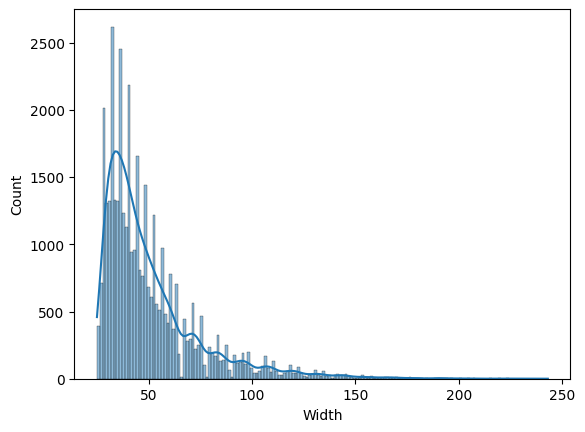

In [7]:
sns.histplot(data = df_train, x = 'Width', kde = True)

<Axes: xlabel='Height', ylabel='Count'>

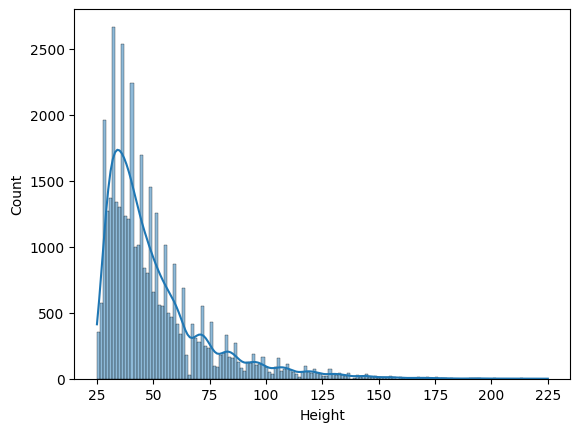

In [8]:
sns.histplot(data = df_train, x = 'Height', kde = True)

Text(0, 0.5, 'Count')

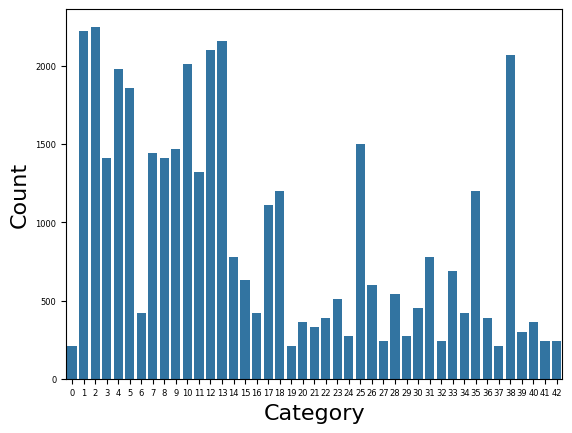

In [9]:
ax = sns.countplot(data = df_train, x = 'ClassId')
ax.tick_params(axis='both', labelsize=6)
ax.set_xlabel('Category', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

In [10]:
value_count = df_train['ClassId'].value_counts() / len(df_train)
print(value_count.sort_values(ascending= False))

ClassId
2     0.057385
1     0.056620
13    0.055089
12    0.053559
38    0.052794
10    0.051264
4     0.050499
5     0.047438
25    0.038257
9     0.037491
7     0.036726
3     0.035961
8     0.035961
11    0.033666
35    0.030605
18    0.030605
17    0.028310
14    0.019893
31    0.019893
33    0.017572
15    0.016068
26    0.015303
28    0.013772
23    0.013007
30    0.011477
6     0.010712
16    0.010712
34    0.010712
22    0.009947
36    0.009947
20    0.009182
40    0.009182
21    0.008416
39    0.007651
29    0.006886
24    0.006886
42    0.006121
32    0.006121
27    0.006121
41    0.006121
0     0.005356
19    0.005356
37    0.005356
Name: count, dtype: float64


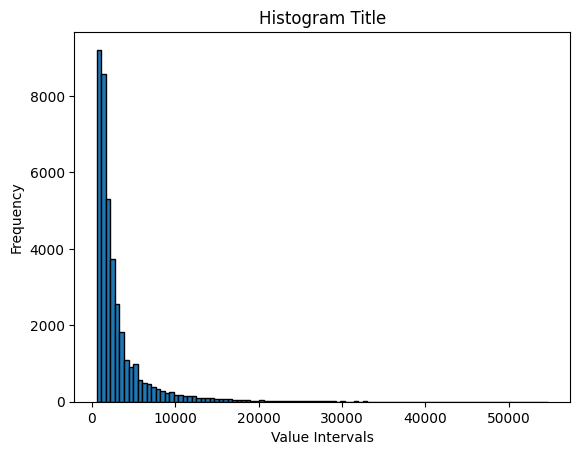

In [11]:
plt.hist(df_train["Height"]*df_train["Width"], bins=100, edgecolor='black')
plt.title('Histogram Title')
plt.xlabel('Value Intervals')
plt.ylabel('Frequency')
plt.show()

### Load Images

In [12]:
base_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
def load_images(df, target_size=(32, 32)):
    images = []
    labels = []
    for idx in range(df.shape[0]):
        roi = df.iloc[idx,2:6]
        img_path = os.path.join(base_path,df.loc[idx,"Path"])
        with Image.open(img_path) as img:
            crop_box = (roi["Roi.X1"],roi["Roi.Y1"],roi["Roi.X2"],roi["Roi.Y2"])
            img = img.crop(crop_box)
            img = img.resize(target_size)
            images.append(img)
            labels.append(df.loc[idx,"ClassId"])
    return np.array(images), np.array(labels)


In [13]:
X_train,y_train = load_images(df_train)
X_test,y_test = load_images(df_test)

In [14]:
print(len(X_train), len(y_train))

39209 39209


### Sample Img per class

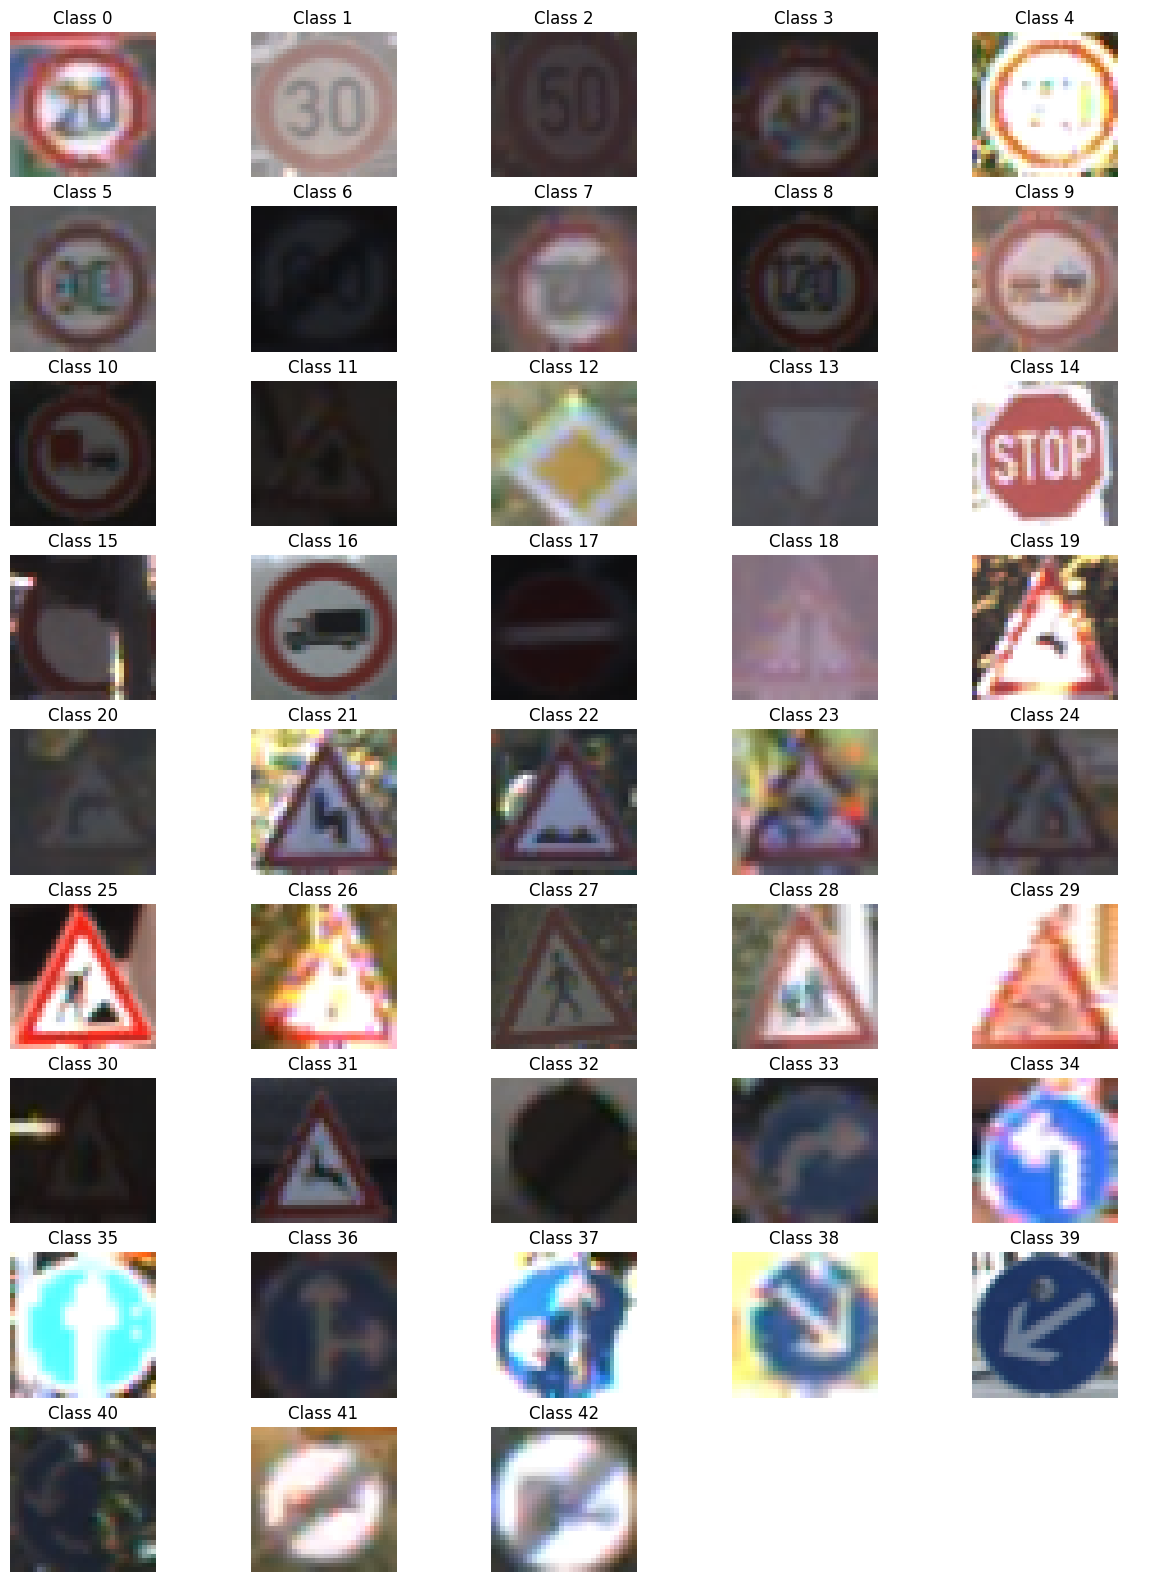

In [101]:
fig, axes = plt.subplots(9, 5, figsize= (15, 20))
for i, ax in enumerate(axes.flatten()):
  if i > 42:
    ax.axis('off')
    continue
  img = X_train[y_train == i][0]
  ax.imshow(img)
  ax.set_title(f'Class {i}')
  ax.axis('off')

### Pixels stats

In [102]:
def pixel_stats(X):

  flatten_img = X.flatten()
  Stats = {
      'mean': [np.mean(flatten_img)],
      'median': [np.median(flatten_img)],
      'std': [np.std(flatten_img)],
      'max': [np.max(flatten_img)],
      'min': [np.min(flatten_img)],
  }
  return pd.DataFrame(Stats)

In [103]:
stats = pixel_stats(X_train)
stats = stats.T.rename(columns={0: 'value'})
print(stats)

             value
mean     85.972866
median   63.000000
std      68.114775
max     255.000000
min       0.000000


In [104]:
#Flattening
images = X_train.reshape(X_train.shape[0], -1)
labels = y_train
images = images / 255
scaler = StandardScaler()
images_scaled = scaler.fit_transform(images)

In [105]:
#PCA implementation
pca = PCA(n_components=100)
image_pca = pca.fit_transform(images_scaled)
print(image_pca.shape)

#LDA implementation
lda = LDA(n_components=2)
image_lda = lda.fit_transform(image_pca, labels)
print(image_lda.shape)

(39209, 100)
(39209, 2)


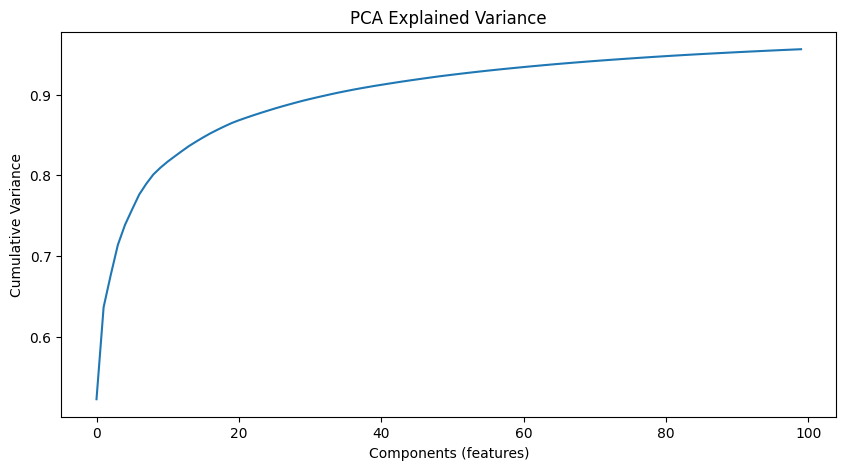

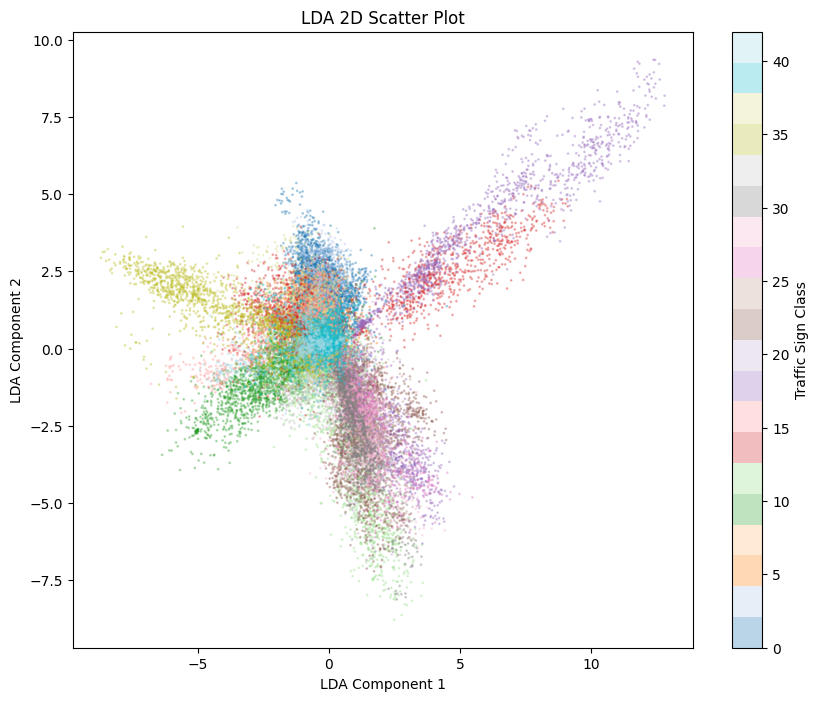

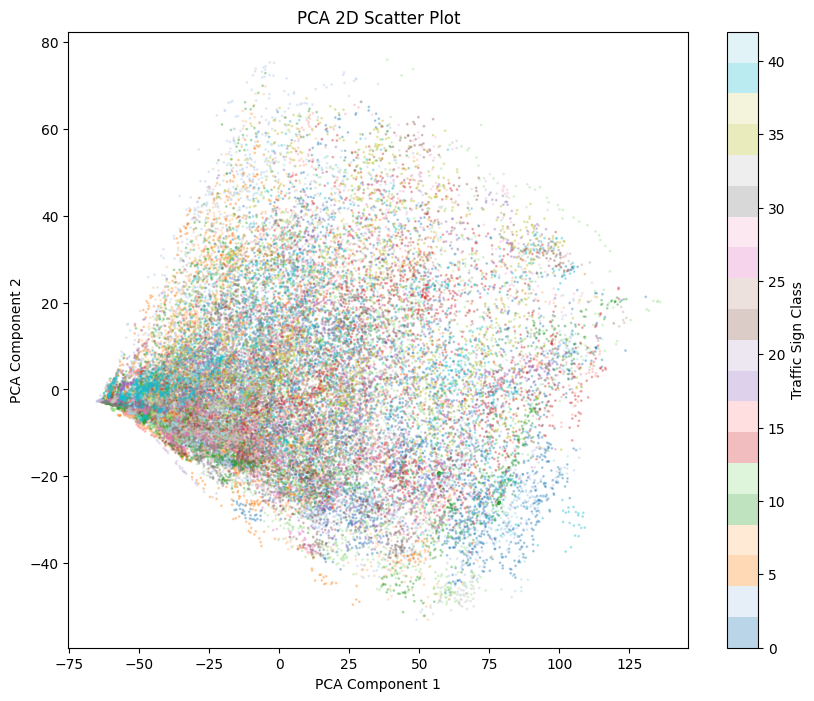

In [106]:
#Plot 1 : PCA explained variance
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('PCA Explained Variance')
plt.xlabel('Components (features)')
plt.ylabel('Cumulative Variance')
plt.show()

#Plot 2 : LDA 2D Scatter Plot
plt.figure(figsize=(10,8))
plt.scatter(image_lda[:,0], image_lda[:,1], c=labels, cmap='tab20', alpha=0.3, s=1)
plt.title('LDA 2D Scatter Plot')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.colorbar(label='Traffic Sign Class')
plt.show()


#Plot 3 : PCA 2D Scatter Plot
plt.figure(figsize=(10,8))
plt.scatter(image_pca[:,0], image_pca[:,1], c=labels, cmap='tab20', alpha=0.3, s=1)
plt.title('PCA 2D Scatter Plot')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Traffic Sign Class')
plt.show()

In [107]:



# Flatten and scale test images the same way as training
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255
X_test_scaled = scaler.transform(X_test_flat)

In [108]:



# -------------------------
# 1. Naive Bayes Classifier
# -------------------------
nb_clf = GaussianNB()
nb_clf.fit(images_scaled, labels)
y_pred_nb = nb_clf.predict(X_test_scaled)

print("=== Naive Bayes Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


=== Naive Bayes Performance ===
Accuracy: 0.19034045922406967

Classification Report:
               precision    recall  f1-score   support

           0       0.04      0.37      0.08        60
           1       0.30      0.30      0.30       720
           2       0.23      0.11      0.15       750
           3       0.12      0.24      0.16       450
           4       0.00      0.00      0.00       660
           5       0.15      0.19      0.17       630
           6       0.04      0.76      0.07       150
           7       0.09      0.10      0.09       450
           8       0.07      0.08      0.07       450
           9       0.64      0.14      0.22       480
          10       0.00      0.00      0.00       660
          11       0.52      0.03      0.05       420
          12       0.99      0.19      0.31       690
          13       0.53      0.46      0.49       720
          14       0.86      0.44      0.58       270
          15       0.40      0.32      0.36     

In [109]:


# -------------------------
# 2. KNN Classifier
# -------------------------
knn_clf = KNeighborsClassifier(n_neighbors=5)  # you can tune k
knn_clf.fit(images_scaled, labels)
y_pred_knn = knn_clf.predict(X_test_scaled)

print("=== KNN Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

=== KNN Performance ===
Accuracy: 0.5577197149643706

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.27      0.26        60
           1       0.43      0.45      0.44       720
           2       0.37      0.37      0.37       750
           3       0.29      0.32      0.31       450
           4       0.48      0.52      0.50       660
           5       0.30      0.47      0.37       630
           6       0.58      0.51      0.55       150
           7       0.34      0.36      0.35       450
           8       0.39      0.36      0.37       450
           9       0.69      0.51      0.58       480
          10       0.76      0.75      0.76       660
          11       0.60      0.50      0.54       420
          12       0.92      0.76      0.83       690
          13       0.95      0.97      0.96       720
          14       0.99      0.72      0.83       270
          15       0.79      0.65      0.71       210
   

In [110]:
print(len(X_train), len(y_train))

39209 39209


In [111]:
from tensorflow.keras import Input
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Normalize images for CNN
X_train_cnn = X_train / 255.0
X_test_cnn = X_test / 255.0

model = Sequential([
    Input(shape=(32,32,3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(43, activation='softmax')
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629,739 (2.40 MB)

 Trainable params: 629,291 (2.40 MB)

 Non-trainable params: 448 (1.75 KB)

In [112]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

In [113]:
print(len(X_train_cnn), len(y_train))

39209 39209


In [114]:
# Split
X_train_cnn, X_val_cnn, y_train, y_val = train_test_split(
    X_train_cnn, y_train, test_size=0.2, random_state=42
)

In [115]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator



# Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1
)

datagen.fit(X_train_cnn)

# Training
history = model.fit(
    datagen.flow(X_train_cnn, y_train, batch_size=64),
    epochs=30,
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stop, reduce_lr]
)

# Test
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print(test_acc)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


491/491 ━━━━━━━━━━━━━━━━━━━━ 61s 117ms/step - accuracy: 0.3180 - loss: 2.6441 - val_accuracy: 0.6880 - val_loss: 0.9730 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 56s 115ms/step - accuracy: 0.7978 - loss: 0.6350 - val_accuracy: 0.9753 - val_loss: 0.0888 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 58s 118ms/step - accuracy: 0.9108 - loss: 0.2872 - val_accuracy: 0.9899 - val_loss: 0.0344 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 56s 115ms/step - accuracy: 0.9378 - loss: 0.2069 - val_accuracy: 0.9790 - val_loss: 0.0681 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 58s 119ms/step - accuracy: 0.9542 - loss: 0.1466 - val_accuracy: 0.9922 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 58s 118ms/step - accuracy: 0.9652 - loss: 0.1088 - val_accuracy: 0.9916 - val_loss: 0.0295 - learning_rate: 0.0010
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 57s 115ms/step - accuracy: 0.9647 - loss:

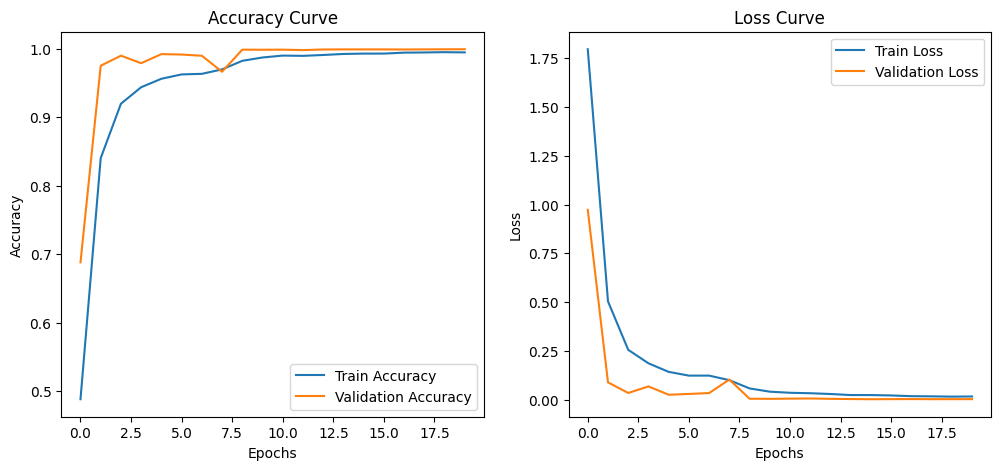

In [116]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [117]:
plot_model(model, to_file='cnn_architecture.png', show_shapes=True, show_layer_names=True)
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print("CNN Test Accuracy:", test_acc)

395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9838 - loss: 0.0732
CNN Test Accuracy: 0.9847980737686157


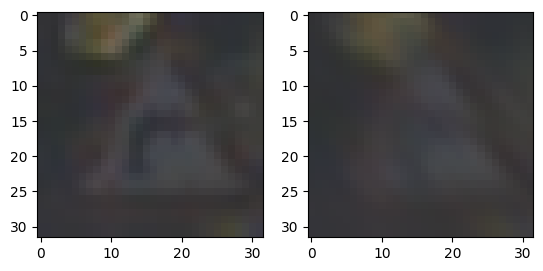

In [118]:
import cv2

def apply_custom_kernel(image, kernel_matrix):
    kernel = np.array(kernel_matrix, dtype=np.float32)
    return cv2.filter2D(image, -1, kernel)

motion_blur_kernel = [
    [0.2, 0, 0, 0, 0],
    [0, 0.2, 0, 0, 0],
    [0, 0, 0.2, 0, 0],
    [0, 0, 0, 0.2, 0],
    [0, 0, 0, 0, 0.2]
]

new_img = apply_custom_kernel(X_train[0],motion_blur_kernel)
plt.subplot(121)
plt.imshow(X_train[0])
plt.subplot(122)
plt.imshow(new_img)

In [119]:
def add_noise(data):
    noised_data = []
    for img in data:
        noised_data.append(np.clip(apply_custom_kernel(img,motion_blur_kernel),0,255).astype(np.uint8))
    return np.array(noised_data)

In [120]:
y_train_denoise = X_train.copy()
x_train_denoise = add_noise(y_train_denoise)
x_train_denoise = x_train_denoise/255
y_train_denoise = y_train_denoise/255
x_train_denoise = x_train_denoise.reshape(-1,32,32,3)
y_train_denoise = y_train_denoise.reshape(-1,32,32,3)

In [121]:
autoencoder_model =  Sequential([
    Conv2D(32, (3,3), padding="same",input_shape=(32,32,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    MaxPooling2D((2,2),strides=2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(128, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    UpSampling2D(size=(2,2)),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    UpSampling2D(size=(2,2)),
    Conv2D(32, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(3, (3,3),activation="sigmoid",padding="same")
])
autoencoder_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        36,92

 Total params: 410,115 (1.56 MB)

 Trainable params: 408,963 (1.56 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [122]:
autoencoder_model.compile(optimizer="adam",loss="mse",metrics=["mae"])
history = autoencoder_model.fit(x_train_denoise,y_train_denoise,batch_size=32,epochs=20)

Epoch 1/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 329s 262ms/step - loss: 0.0100 - mae: 0.0663
Epoch 2/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 318s 259ms/step - loss: 0.0033 - mae: 0.0397
Epoch 3/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 318s 260ms/step - loss: 0.0025 - mae: 0.0338
Epoch 4/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 318s 259ms/step - loss: 0.0021 - mae: 0.0314
Epoch 5/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 316s 258ms/step - loss: 0.0020 - mae: 0.0300
Epoch 6/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 316s 258ms/step - loss: 0.0018 - mae: 0.0282
Epoch 7/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 316s 258ms/step - loss: 0.0017 - mae: 0.0274
Epoch 8/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 314s 256ms/step - loss: 0.0016 - mae: 0.0263
Epoch 9/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 316s 258ms/step - loss: 0.0015 - mae: 0.0255
Epoch 10/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 316s 257ms/step - loss: 0.0014 - mae: 0.0251
Epoch 11/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 316s 258ms/step - loss: 0.0014 - mae: 0.0249
Epoch 12/20
1226/1226 ━━━━━━━━━━━━━━━━━━━

In [123]:
autoencoder_model.save("/kaggle/working/autoencoder_model.keras")

In [124]:
print(f'number of classes: {len(np.unique(y_train))}')

number of classes: 43


In [126]:
IMG_SIZE = (96, 96)
CHANNELS = 3
NUM_CLASSES = 43
X_train_scaled = (X_train / 127.5) - 1.0
X_test_scaled = (X_test / 127.5) - 1.0
base_model_pretrained = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
base_model_pretrained.trainable = False 
pre_trained = models.Sequential([
    layers.Resizing(IMG_SIZE[0], IMG_SIZE[1]),
    
    base_model_pretrained,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])


pre_trained.compile(tf.keras.optimizers.legacy.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Starting Training: Pretrained Model...")
history_pretrained = pre_trained.fit(X_train_scaled, y_train, batch_size=32,epochs=10, validation_data=(X_test_scaled, y_test))

base_model_tuning = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
base_model_tuning.trainable = True

fine_tune_at = 100
for layer in base_model_tuning.layers[:fine_tune_at]:
    layer.trainable = False

tuning= models.Sequential([
    layers.Resizing(IMG_SIZE[0], IMG_SIZE[1]),
    
    base_model_tuning,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
tuning.compile(optimizer=tf.keras.optimizers.legacy.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Starting Training: Fine-tuning...")
history_finetuned = tuning.fit(X_train_scaled, y_train, batch_size=32, epochs=10, validation_data=(X_test_scaled, y_test))

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_96_no_top.h5: None -- [Errno -3] Temporary failure in name resolution

## Pretrained vs fine-tuned
| Model State | Optimizer | Training Loss | Training Accuracy | Validation Loss | validation Accuracy |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Pretrained (Frozen)** | Adam | 0.1948 | 0.9325 | 0.8452  | 0.7967 |
| **Fine-tuned (Unfrozen)** | Adam | 0.0182  | 0.9944  | 0.2067  | 0.9618 |

In [127]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

optimizers_to_test = {
    'SGD': tf.keras.optimizers.legacy.SGD(learning_rate=0.01,momentum=0.9),
    'Adam': tf.keras.optimizers.legacy.Adam(learning_rate=0.001),
    'RMSprop': tf.keras.optimizers.legacy.RMSprop(learning_rate=0.001)
}

histories = {}
results = {}

for opt_name,opt in optimizers_to_test.items():
    print(f"Training with {opt_name} ")

    m = Sequential([
        Input(shape=(32, 32, 3)),

        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3),activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128,(3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),

        Dense(43, activation='softmax')
    ])

    m.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-5
    )

    datagen = ImageDataGenerator(
        rotation_range=15,
        zoom_range=0.2,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.1
    )

    datagen.fit(X_train_cnn)

    history = m.fit(
        datagen.flow(X_train_cnn, y_train, batch_size=64),
        epochs=30,
        validation_data=(X_val_cnn, y_val),
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    loss, acc = m.evaluate(X_test_cnn, y_test, verbose=0)

    histories[opt_name] = history
    results[opt_name] = {
        'Test Accuracy': round(acc, 4),
        'Test Loss': round(loss, 4)
    }

    print(f"{opt_name} : Test Accuracy: {acc:.4f}")


# Training Curves 

colors = {'SGD': 'red', 'Adam': 'blue', 'RMSprop': 'green'}
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

for name, h in histories.items():
    plt.plot(h.history['accuracy'], label=name,color=colors[name])
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
for name, h in histories.items():
    plt.plot(h.history['val_accuracy'],label=name, color=colors[name])
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


# Metrics Table

rows = []
for name, h in histories.items():
    rows.append({
        'Optimizer': name,
        'Final Train Acc': round(h.history['accuracy'][-1], 4),
        'Final Val Acc': round(h.history['val_accuracy'][-1], 4),
        'Best Val Acc': round(max(h.history['val_accuracy']), 4),
        'Best Val Epoch': int(np.argmax(h.history['val_accuracy'])) + 1,
        'Test Accuracy': results[name]['Test Accuracy'],
        'Test Loss': results[name]['Test Loss'],
    })

df_optimizers = pd.DataFrame(rows).set_index('Optimizer')
print(df_optimizers)

ImportError: `keras.optimizers.legacy` is not supported in Keras 3. When using `tf.keras`, to continue using a `tf.keras.optimizers.legacy` optimizer, you can install the `tf_keras` package (Keras 2) and set the environment variable `TF_USE_LEGACY_KERAS=True` to configure TensorFlow to use `tf_keras` when accessing `tf.keras`.

**RNN**

In [135]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_improved_rnn(input_shape, num_classes):
    model = Sequential()
    

    model.add(SimpleRNN(256, input_shape=input_shape, activation='relu', return_sequences=False))
    
    
    model.add(Dropout(0.2))
    
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2)) 
    
    model.add(Dense(num_classes, activation='softmax'))
    return model


model = build_improved_rnn((32, 32), 43)


optimizer = Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer, 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

history = model.fit(
    X_train_final, y_train_cat, 
    epochs=20, 
    batch_size=64, 
    validation_data=(X_test_final, y_test_cat)
)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 256)            │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,427 (439.17 KB)

 Trainable params: 112,427 (439.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.0464 - loss: 3.6493 - val_accuracy: 0.0578 - val_loss: 3.4955
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.0523 - loss: 3.5284 - val_accuracy: 0.0570 - val_loss: 3.4711
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.0541 - loss: 3.5108 - val_accuracy: 0.0585 - val_loss: 3.4778
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.0539 - loss: 3.5012 - val_accuracy: 0.0606 - val_loss: 3.4794
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.0533 - loss: 3.5011 - val_accuracy: 0.0575 - val_loss: 3.4718
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.0567 - loss: 3.5035 - val_accuracy: 0.0592 - val_loss: 3.4691
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.0580 - loss: 3.5005 - val_accuracy: 0.0581 - val_loss: 3.4684
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.0576 - loss: 3.4916 - 

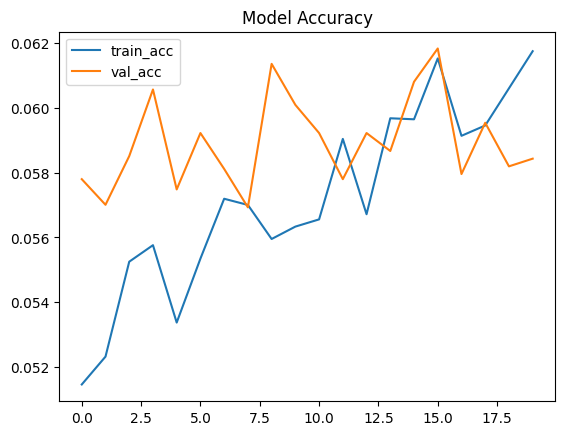

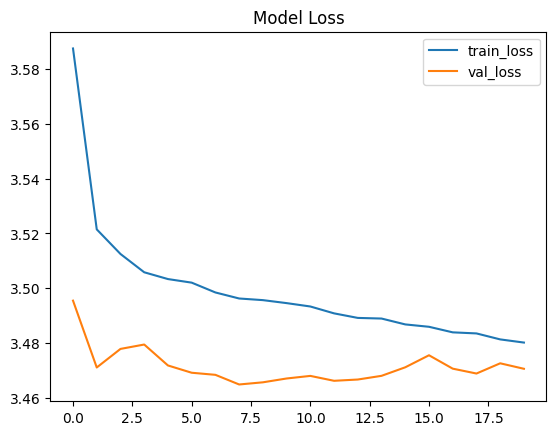

In [136]:
import matplotlib.pyplot as plt


plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()


plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.legend()
plt.show()

**LSTM**

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import pandas as pd

X_train_lstm = X_train.reshape(X_train.shape[0], 32, 96).astype('float32') / 255.0
X_test_lstm = X_test.reshape(X_test.shape[0], 32, 96).astype('float32') / 255.0

#1-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=43)
y_test_cat = to_categorical(y_test, num_classes=43)

# split validation set
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val_cat = train_test_split(
    X_train_lstm, y_train_cat, test_size=0.2, random_state=42
)

print("X_train shape:", X_tr.shape)
print("X_test shape: ", X_test_lstm.shape)


X_train shape: (31367, 32, 96)
X_test shape:  (12630, 32, 96)


In [16]:
#Building 

lstm_model = Sequential([
    LSTM(128, input_shape=(32, 96), return_sequences=True),
    Dropout(0.3),

    LSTM(64, return_sequences=False),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(43, activation='softmax')
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

2026-05-13 11:51:34.378180: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32, 128)        │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,475 (697.17 KB)

 Trainable params: 178,475 (697.17 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#Training 

early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-5)

history = lstm_model.fit(
    X_tr, y_tr,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 66ms/step - accuracy: 0.1813 - loss: 2.9692 - val_accuracy: 0.5719 - val_loss: 1.3253 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.6088 - loss: 1.1837 - val_accuracy: 0.8124 - val_loss: 0.5998 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7910 - loss: 0.6566 - val_accuracy: 0.8671 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.8656 - loss: 0.4406 - val_accuracy: 0.8849 - val_loss: 0.3874 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.9026 - loss: 0.3307 - val_accuracy: 0.9444 - val_loss: 0.1918 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.9369 - loss: 0.2143 - val_accuracy: 0.9523 - val_loss: 0.1671 - learning_rate: 0.0010
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.9462 - l

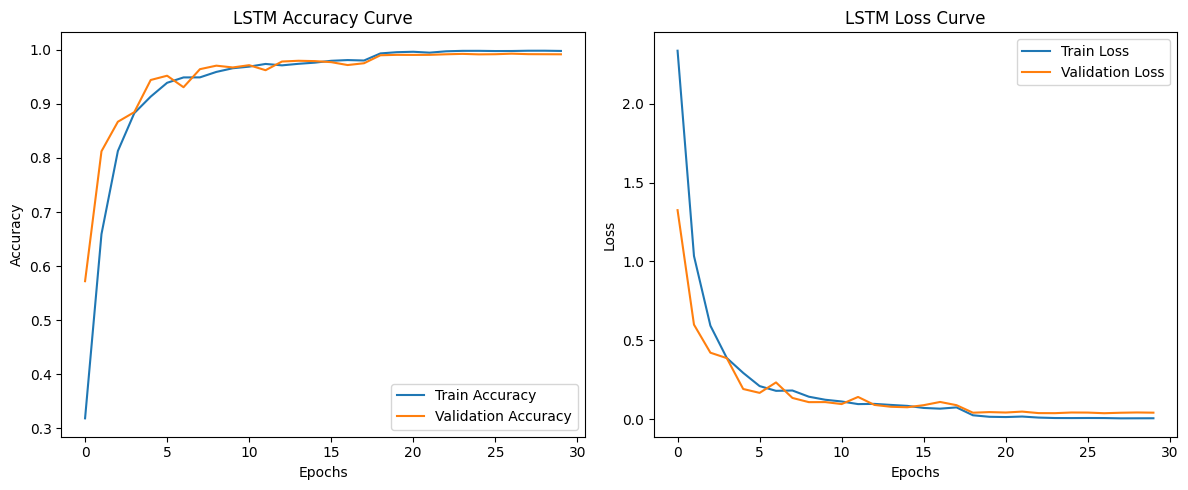

In [18]:
#Plotting training curves 

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [19]:
#Evaluation

test_loss, test_acc = lstm_model.evaluate(X_test_lstm, y_test_cat, verbose=0)
print(f"LSTM Test Accuracy: {test_acc:.4f}")
print(f"LSTM Test Loss: {test_loss:.4f}")

LSTM Test Accuracy: 0.9335
LSTM Test Loss: 0.4339
